# Violencia en Tech — Notebook 02: Análisis Exploratorio de Datos (EDA)

**Proyecto:** Sistema de Análisis de Violencia Simbólica contra Mujeres en Tecnología  
**Autora:** Maricarmen Camacho Pérez — UAEH, Ciencias Computacionales  
**Input:** `data/raw/reddit_data_raw_<timestamp>.csv`  
**Output:** `data/processed/reddit_data_analizado.csv` + figuras de análisis  

---
**Pipeline:** 01_Extraccion → **02_EDA** → 03_Limpieza → 04_Reglas → 05_BERT → 06_Temporal → Final

---

### ¿Qué hace este notebook?
1. Carga el dataset crudo generado por el Notebook 01
2. Calcula estadísticas generales del corpus (volumen, tipos, longitud)
3. Genera 3 visualizaciones para entender los datos:
   - Figura general del corpus (volumen por año, posts vs comentarios, top subreddits)
   - Timeline mensual con eventos históricos marcados
   - Heatmap de actividad por subreddit × año
4. Guarda el dataset con columnas nuevas para los siguientes notebooks

---
## 1. Librerías

In [1]:
# ══════════════════════════════════════════════════════════
# IMPORTACIÓN DE LIBRERÍAS
# ══════════════════════════════════════════════════════════

import pandas as pd              # Manipulación de datos en tablas (DataFrames)
import numpy as np               # Operaciones numéricas (promedios, estadísticas)
import matplotlib.pyplot as plt  # Crear gráficas y visualizaciones
import matplotlib.gridspec as gridspec  # Para layouts de subplots más flexibles (varios gráficos en 1 figura)
import seaborn as sns            # Gráficas estadísticas más bonitas (heatmaps, etc.)
import glob                      # Buscar archivos por patrón (ej: "*.csv")
import os                        # Manejar rutas de archivos y carpetas
from datetime import datetime    # Manejar fechas
import warnings                  # Controlar mensajes de advertencia

# Desactivar warnings para que la salida se vea limpia
warnings.filterwarnings("ignore")

# ══════════════════════════════════════════════════════════
# PALETA DE COLORES
# Se define una sola vez y se usa en todas las gráficas
# para que el proyecto tenga una identidad visual consistente
# ══════════════════════════════════════════════════════════

PALETTE = {
    "primario":    "#2C5F8A",   # Azul oscuro — barras principales, líneas
    "secundario":  "#E84E4F",   # Rojo — eventos históricos, acentos de alerta
    "acento":      "#F5A623",   # Naranja/dorado — pie charts, categorías secundarias
    "neutral":     "#4CAF50",   # Verde — categoría neutral
    "fondo":       "#FAFAFA",   # Gris muy claro — fondo de gráficas
}

# Crear carpeta de imágenes si no existe
# os.makedirs crea la carpeta; exist_ok=True evita error si ya existe
os.makedirs("../images/exploratorio", exist_ok=True)

print(f"Fecha de ejecución: {datetime.now().strftime('%Y-%m-%d %H:%M')}")
print(f"Pandas: {pd.__version__}")

Fecha de ejecución: 2026-03-18 19:00
Pandas: 3.0.1


---
## 2. Cargar datos

Buscamos automáticamente el CSV más reciente generado por el Notebook 01.  
El archivo está en `data/raw/` con nombre `reddit_data_raw_<timestamp>.csv`.

In [2]:
# ══════════════════════════════════════════════════════════
# CARGAR EL DATASET CRUDO
# Busca el archivo más reciente en data/raw/ por el timestamp del nombre
# ══════════════════════════════════════════════════════════

# glob.glob busca todos los archivos que coincidan con el patrón
# sorted() los ordena alfabéticamente (como tienen timestamp, el último es el más reciente)
archivos = sorted(glob.glob("../data/raw/reddit_data_raw_*.csv"))

if archivos:
    archivo = archivos[-1]   # [-1] toma el último de la lista (el más reciente)
    print(f"Cargando: {archivo}")
    df = pd.read_csv(archivo)  # Leer el CSV y convertirlo en DataFrame
else:
    # Si no encuentra ningún archivo con ese patrón, intentar nombre genérico
    raise FileNotFoundError(
        "No se encontró ningún archivo reddit_data_raw_*.csv en ../data/raw/\n"
        "Asegúrate de haber corrido el Notebook 01 primero."
    )

# ══════════════════════════════════════════════════════════
# PREPARAR COLUMNAS DE TIEMPO
# La columna "fecha" viene como texto en el CSV, hay que convertirla
# a datetime para poder hacer operaciones con fechas
# ══════════════════════════════════════════════════════════

# Convertir la columna "fecha" de string a datetime con zona horaria UTC
df["fecha"] = pd.to_datetime(df["fecha"], utc=True)

# Crear columnas auxiliares de tiempo que usaremos en los análisis
# Si ya vienen del notebook 01, las sobrescribimos para asegurar consistencia
df["año"]      = df["fecha"].dt.year             # Año: 2016, 2017, ..., 2026
df["mes"]      = df["fecha"].dt.month            # Mes: 1, 2, ..., 12
df["año_mes"]  = df["fecha"].dt.to_period("M")   # Período mensual: 2016-01, 2016-02, ...
df["trimestre"]= df["fecha"].dt.to_period("Q")   # Trimestre: 2016Q1, 2016Q2, ...

# Resumen de lo que se cargó
print(f"\nDataset cargado: {len(df):,} registros × {len(df.columns)} columnas")
print(f"Período: {df['año'].min()} – {df['año'].max()}")
print(f"Subreddits: {df['subreddit'].nunique()}")

Cargando: ../data/raw\reddit_data_raw_20260318_174918.csv

Dataset cargado: 201,182 registros × 16 columnas
Período: 2016 – 2026
Subreddits: 20



#### NORMALIZAR NOMBRES DE SUBREDDITS
Reddit no distingue mayúsculas/minúsculas en los nombres, pero la API a veces devuelve variantes diferentes.
Ejemplo: "WomenInTech" y "womenintech" son el mismo subreddit.
Aquí los unificamos al nombre canónico (el que se uso en el notebook 01).


In [6]:


# Diccionario de corrección: variante incorrecta → nombre canónico
# La clave es el nombre en minúsculas, el valor es el nombre que queremos usar
NOMBRES_CANONICOS = {
    "womenintech":    "WomenInTech",
    "experienceddevs":"experienceddevs",
    "womenengineers": "WomenEngineers",
}

# Función que recibe un nombre y lo corrige si es necesario
def normalizar_subreddit(nombre):
    """Convierte variantes de un mismo subreddit al nombre canónico."""
    return NOMBRES_CANONICOS.get(nombre.lower(), nombre)
    # .get(clave, default): busca la clave en el diccionario
    # Si la encuentra, devuelve el valor canónico
    # Si no la encuentra, devuelve el nombre original sin cambios

# Aplicar la normalización a toda la columna
antes = df["subreddit"].nunique()  # Cuántos subreddits antes de normalizar
df["subreddit"] = df["subreddit"].apply(normalizar_subreddit)
despues = df["subreddit"].nunique()  # Cuántos después

print(f"Subreddits antes de normalizar : {antes}")
print(f"Subreddits después             : {despues}")
print(f"Variantes corregidas           : {antes - despues}")

Subreddits antes de normalizar : 20
Subreddits después             : 17
Variantes corregidas           : 3


---
## 3. Estadísticas descriptivas generales

Antes de graficar, calculamos los números básicos del corpus  
para tener una visión general de qué tenemos.

In [7]:
# ══════════════════════════════════════════════════════════
# ESTADÍSTICAS GENERALES DEL CORPUS
# Este bloque imprime un resumen completo de los datos
# ══════════════════════════════════════════════════════════

print("=" * 65)
print("ESTADÍSTICAS GENERALES DEL CORPUS")
print("=" * 65)

# ── Rango temporal ───────────────────────────────────────
print(f"\nRango temporal:")
print(f"  Fecha más antigua  : {df['fecha'].min().strftime('%Y-%m-%d')}")  # Primera fecha
print(f"  Fecha más reciente : {df['fecha'].max().strftime('%Y-%m-%d')}")  # Última fecha
print(f"  Años cubiertos     : {df['año'].nunique()}")  # Cuántos años distintos hay

# ── Volumen de datos ─────────────────────────────────────
print(f"\nVolumen:")
print(f"  Total de textos    : {len(df):,}")  # Total de registros
n_posts = (df["tipo"] == "post").sum()        # Contar posts
n_comments = (df["tipo"] == "comment").sum()  # Contar comentarios
print(f"  Posts              : {n_posts:,} ({n_posts/len(df)*100:.1f}%)")  # Posts con porcentaje
print(f"  Comentarios        : {n_comments:,} ({n_comments/len(df)*100:.1f}%)")  # Comentarios con %

# ── Subreddits ───────────────────────────────────────────
print(f"\nSubreddits únicos: {df['subreddit'].nunique()}")
print("\nVolumen por subreddit:")
# value_counts() cuenta cuántos textos hay de cada subreddit, ordenados de mayor a menor
for sub, count in df["subreddit"].value_counts().items():
    print(f"  {sub:25s} : {count:>7,} ({count/len(df)*100:5.1f}%)")  # Alineado con porcentaje

# ── Longitud de textos ───────────────────────────────────
# Calcular métricas de longitud que usaremos en gráficas posteriores
# fillna("") reemplaza valores nulos por string vacío para evitar errores
df["texto_completo"] = df["texto_completo"].fillna("").astype(str)
df["num_palabras"]   = df["texto_completo"].apply(lambda x: len(x.split()))  # Contar palabras
df["num_caracteres"] = df["texto_completo"].apply(len)  # Contar caracteres

print(f"\nLongitud de textos (palabras):")
print(f"  Mediana  : {df['num_palabras'].median():.0f}")  # Valor del medio
print(f"  Promedio : {df['num_palabras'].mean():.1f}")    # Promedio (afectado por outliers)
print(f"  Mínimo   : {df['num_palabras'].min()}")         # Texto más corto
print(f"  Máximo   : {df['num_palabras'].max():,}")       # Texto más largo

ESTADÍSTICAS GENERALES DEL CORPUS

Rango temporal:
  Fecha más antigua  : 2016-01-03
  Fecha más reciente : 2026-03-18
  Años cubiertos     : 11

Volumen:
  Total de textos    : 201,182
  Posts              : 13,971 (6.9%)
  Comentarios        : 187,211 (93.1%)

Subreddits únicos: 17

Volumen por subreddit:
  TwoXChromosomes           :  30,022 ( 14.9%)
  antiwork                  :  24,582 ( 12.2%)
  cscareerquestions         :  22,459 ( 11.2%)
  WomenInTech               :  14,968 (  7.4%)
  experienceddevs           :  14,509 (  7.2%)
  ITCareerQuestions         :  13,454 (  6.7%)
  learnprogramming          :  11,915 (  5.9%)
  webdev                    :  11,739 (  5.8%)
  datascience               :   9,508 (  4.7%)
  WomenEngineers            :   9,029 (  4.5%)
  AskWomen                  :   8,415 (  4.2%)
  girlsgonewired            :   8,165 (  4.1%)
  MachineLearning           :   5,558 (  2.8%)
  technology                :   5,529 (  2.7%)
  LadiesofScience           :   4

---
## 4. Visualización general del corpus

Esta figura combina 4 gráficas en una sola imagen:  
- Volumen de textos por año  
- Posts vs comentarios  
- Top 12 subreddits  
- Distribución de longitud de textos  

Se guarda como `02_exploratorio_general.png` 

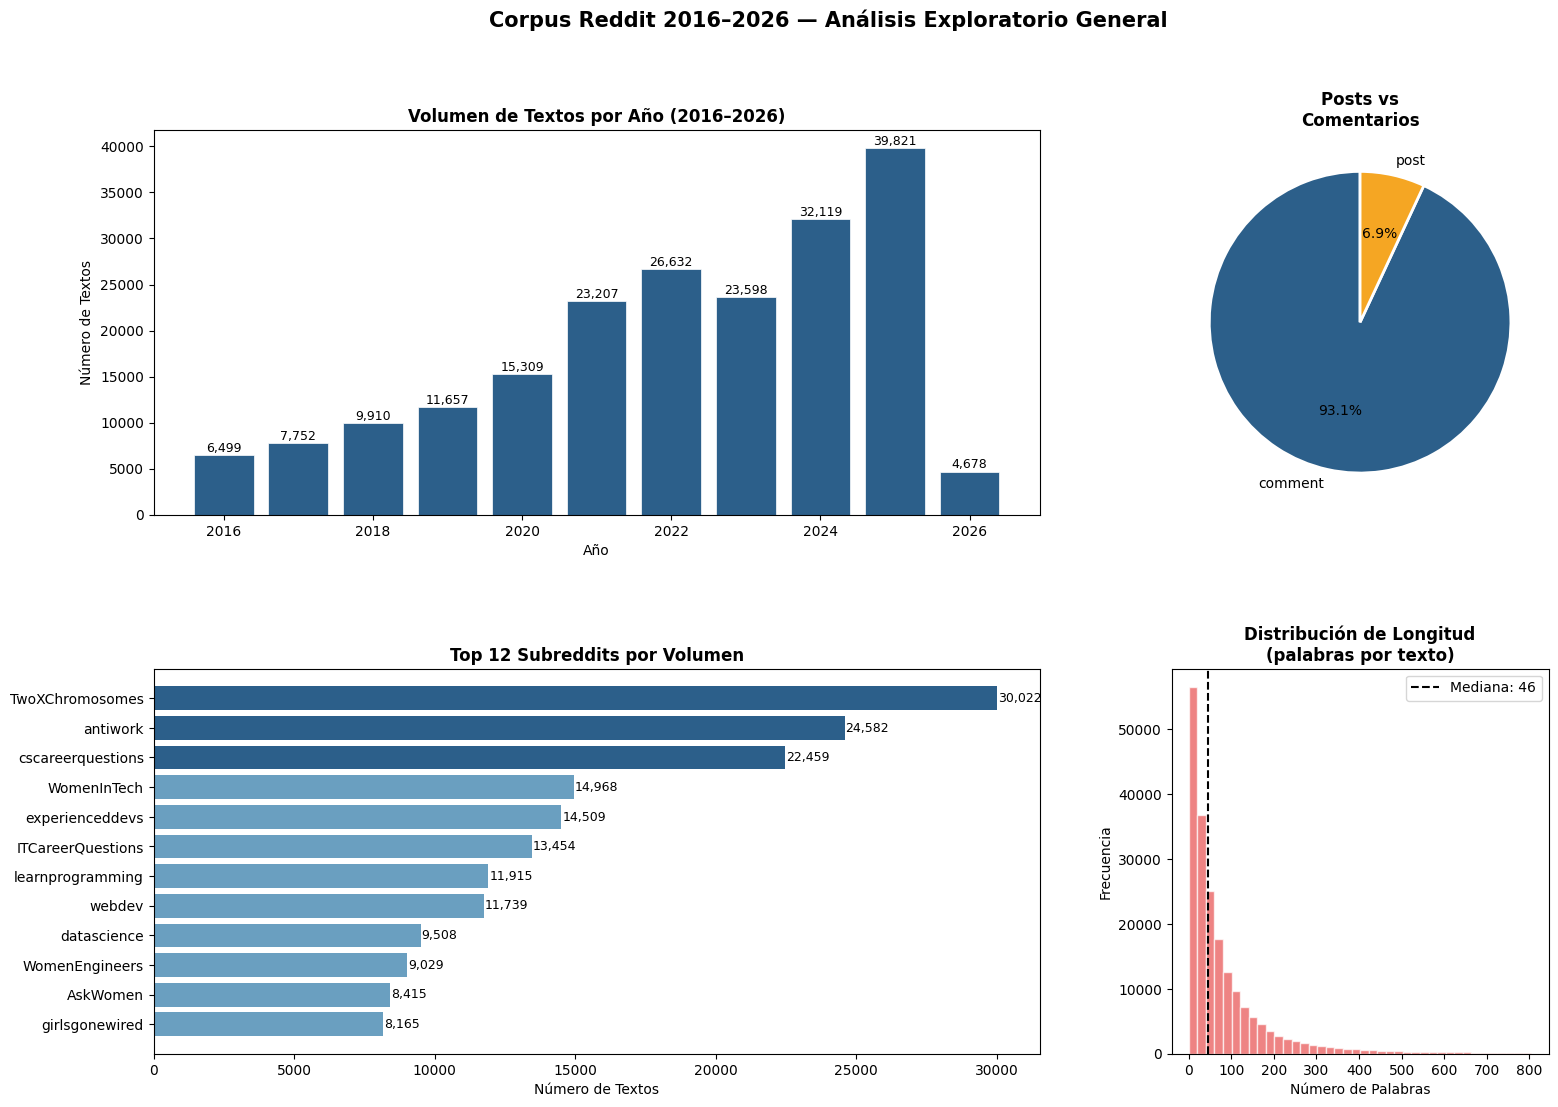

Figura guardada: ../images/exploratorio/02_exploratorio_general.png


In [ ]:
# ══════════════════════════════════════════════════════════
# FIGURA GENERAL DEL CORPUS (4 paneles)
# ══════════════════════════════════════════════════════════

# Crear una figura grande con espacio para 4 gráficas
# figsize=(18, 12) define el tamaño en pulgadas (ancho, alto)
fig = plt.figure(figsize=(18, 12))

# Título principal de toda la figura
fig.suptitle("Corpus Reddit 2016–2026 — Análisis Exploratorio General",
            fontsize=15, fontweight="bold", y=0.98)

# GridSpec permite controlar cómo se distribuyen las gráficas
# 2 filas × 3 columnas, con espacio entre ellas
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# ── Gráfica 1: Volumen de textos por año (ocupa 2 columnas) ──
ax1 = fig.add_subplot(gs[0, :2])  # Fila 0, columnas 0 y 1

# Contar textos por año y ordenar cronológicamente
por_año = df["año"].value_counts().sort_index()

# Crear barras
bars = ax1.bar(por_año.index, por_año.values,
            color=PALETTE["primario"],    # Color azul
            edgecolor="white",            # Borde blanco entre barras
            linewidth=0.5)                # Grosor del borde

ax1.set_title("Volumen de Textos por Año (2016–2026)", fontweight="bold")
ax1.set_xlabel("Año")
ax1.set_ylabel("Número de Textos")

# Poner el número encima de cada barra para que se lea fácil
for bar in bars:
    h = bar.get_height()  # Altura de la barra = valor
    ax1.text(bar.get_x() + bar.get_width()/2,  # Centrar horizontalmente
            h + 50,                             # Un poco arriba de la barra
            f"{h:,}",                           # Formato con comas (ej: 37,287)
            ha="center", va="bottom", fontsize=9)

# ── Gráfica 2: Posts vs Comentarios (pie chart) ──────────
ax2 = fig.add_subplot(gs[0, 2])  # Fila 0, columna 2

# Contar cuántos posts y cuántos comentarios hay
tipo = df["tipo"].value_counts()

# Crear gráfica de pastel
ax2.pie(tipo.values,
        labels=tipo.index,           # Etiquetas: "comment", "post"
        autopct="%1.1f%%",           # Mostrar porcentaje con 1 decimal
        colors=[PALETTE["primario"], PALETTE["acento"]],  # Azul y naranja
        startangle=90,               # Empezar desde arriba
        wedgeprops={"edgecolor": "white", "linewidth": 2})  # Bordes blancos
ax2.set_title("Posts vs\nComentarios", fontweight="bold")

# ── Gráfica 3: Top 12 subreddits (barras horizontales) ──
ax3 = fig.add_subplot(gs[1, :2])  # Fila 1, columnas 0 y 1

# Obtener los 12 subreddits con más textos
top_subs = df["subreddit"].value_counts().head(12)

# Los 3 primeros van en azul oscuro, el resto en azul más claro
colors_subs = [PALETTE["primario"] if i < 3 else "#6A9FC0" for i in range(len(top_subs))]

# Crear barras horizontales
ax3.barh(range(len(top_subs)), top_subs.values, color=colors_subs)
ax3.set_yticks(range(len(top_subs)))             # Posición de etiquetas
ax3.set_yticklabels(top_subs.index, fontsize=10)  # Nombres de subreddits
ax3.set_title("Top 12 Subreddits por Volumen", fontweight="bold")
ax3.set_xlabel("Número de Textos")
ax3.invert_yaxis()  # Invertir para que el más grande quede arriba

# Poner el número al final de cada barra
for i, v in enumerate(top_subs.values):
    ax3.text(v + 30, i, f"{v:,}", va="center", fontsize=9)

# ── Gráfica 4: Distribución de longitud de textos ────────
ax4 = fig.add_subplot(gs[1, 2])  # Fila 1, columna 2

# Recortar outliers extremos usando percentil 99
# Sin esto, unos pocos textos larguísimos aplastan el histograma
limite = df["num_palabras"].quantile(0.99)  # Encontrar el valor del percentil 99
datos_hist = df[df["num_palabras"] <= limite]["num_palabras"]  # Solo textos debajo del límite

# Crear histograma
ax4.hist(datos_hist, bins=40,                      # 40 barras
        color=PALETTE["secundario"], alpha=0.7,    # Rojo semitransparente
        edgecolor="white")                          # Bordes blancos

# Línea vertical en la mediana para mostrar el valor típico
mediana = df["num_palabras"].median()
ax4.axvline(mediana, color="black", linestyle="--", linewidth=1.5,
            label=f"Mediana: {mediana:.0f}")  # Etiqueta para la leyenda

ax4.set_title("Distribución de Longitud\n(palabras por texto)", fontweight="bold")
ax4.set_xlabel("Número de Palabras")
ax4.set_ylabel("Frecuencia")
ax4.legend()  # Mostrar la leyenda con la mediana

# ── Guardar la figura ────────────────────────────────────
ruta_fig = "../images/exploratorio/02_exploratorio_general.png"
plt.savefig(ruta_fig, dpi=150, bbox_inches="tight")  # dpi=150 para buena resolución
plt.show()
print(f"Figura guardada: {ruta_fig}")

---
## 5. Timeline mensual con eventos históricos

Esta gráfica muestra cómo fue creciendo la actividad mes a mes,  
con líneas verticales que marcan eventos importantes como #MeToo,  
Google Walkout, COVID-19, despidos tech y el boom de ChatGPT.  

Se guarda como `02_timeline_mensual.png` (Figura 6 del artículo).

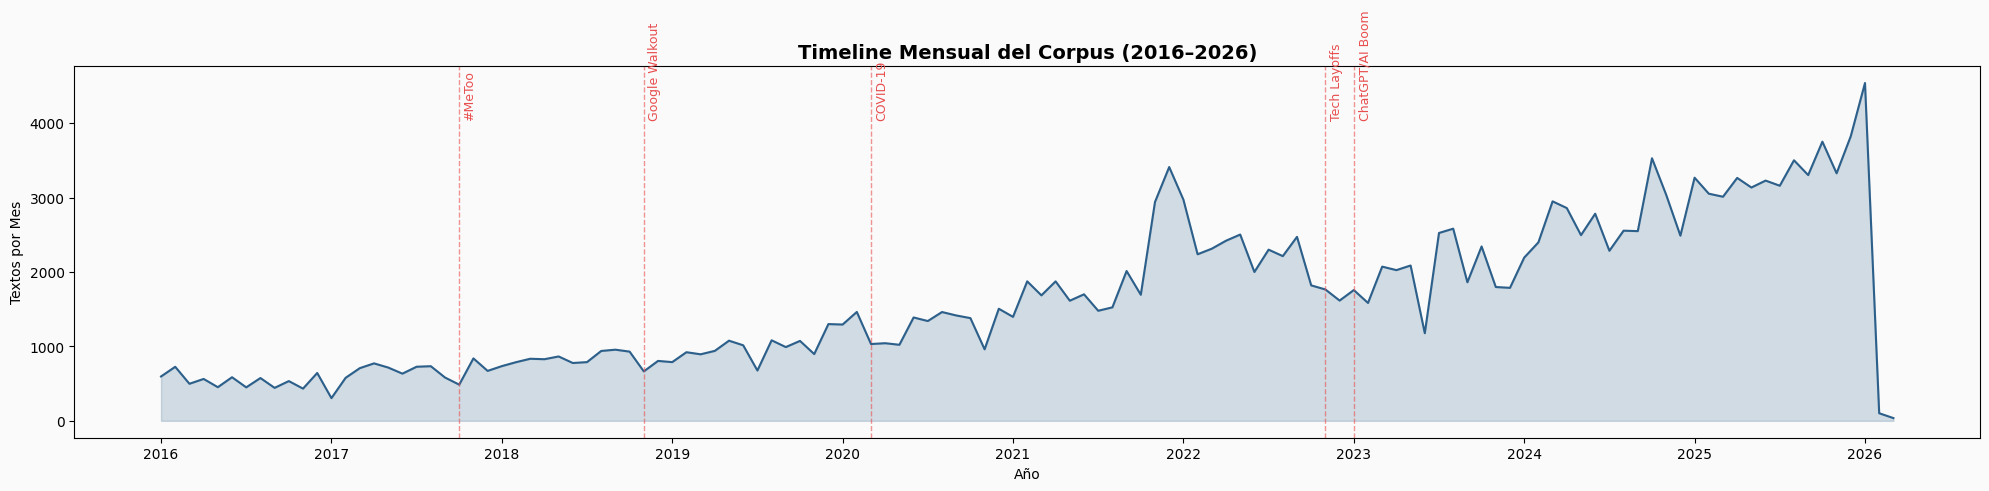

Figura guardada: ../images/exploratorio/02_timeline_mensual.png


In [9]:
# ══════════════════════════════════════════════════════════
# TIMELINE MENSUAL CON EVENTOS HISTÓRICOS
# ══════════════════════════════════════════════════════════

# Crear figura ancha y no muy alta (ideal para timelines)
fig, ax = plt.subplots(figsize=(20, 5))
fig.patch.set_facecolor(PALETTE["fondo"])  # Fondo gris claro de la figura
ax.set_facecolor(PALETTE["fondo"])          # Fondo gris claro del área de dibujo

# Agrupar textos por mes para ver la evolución granular
# .size() cuenta cuántos registros hay en cada mes
por_mes = df.groupby("año_mes").size()

# ── Dibujar la línea de tendencia ────────────────────────
# fill_between crea el área sombreada debajo de la línea
ax.fill_between(range(len(por_mes)), por_mes.values,
                color=PALETTE["primario"], alpha=0.2)  # Azul semitransparente

# La línea principal encima del área sombreada
ax.plot(range(len(por_mes)), por_mes.values,
        color=PALETTE["primario"], linewidth=1.5)

# ── Configurar eje X con etiquetas de años ──────────────
# Encontrar las posiciones donde empieza cada año (mes == enero)
ticks_años = [i for i, p in enumerate(por_mes.index) if p.month == 1]

ax.set_xticks(ticks_años)  # Poner marcas solo en los eneros
ax.set_xticklabels([str(por_mes.index[i].year) for i in ticks_años])  # Etiqueta: solo el año

# ── Marcar eventos históricos relevantes ─────────────────
# Estos eventos se mencionan en el artículo (sección 3.5) para
# contextualizar las variaciones en la actividad del corpus
eventos = {
    "2017-10": "#MeToo",          # Movimiento contra acoso sexual
    "2018-11": "Google Walkout",   # Protesta masiva de empleados de Google
    "2020-03": "COVID-19",         # Inicio de la pandemia
    "2022-11": "Tech Layoffs",     # Oleada de despidos en tech
    "2023-01": "ChatGPT/AI Boom",  # Auge de la IA generativa
}

# Para cada evento, dibujar una línea vertical roja y el nombre rotado
for fecha_str, nombre in eventos.items():
    periodo = pd.Period(fecha_str, freq="M")  # Convertir string a período mensual
    if periodo in por_mes.index:               # Verificar que ese mes exista en los datos
        idx = list(por_mes.index).index(periodo)  # Encontrar la posición en el eje X
        # Línea vertical punteada roja
        ax.axvline(idx, color=PALETTE["secundario"], linestyle="--", alpha=0.6, linewidth=1)
        # Nombre del evento rotado 90 grados
        ax.text(idx + 0.3, por_mes.max() * 0.9, nombre,
                rotation=90, fontsize=9, color=PALETTE["secundario"])

# ── Títulos y etiquetas ──────────────────────────────────
ax.set_title("Timeline Mensual del Corpus (2016–2026)", fontsize=14, fontweight="bold")
ax.set_ylabel("Textos por Mes")
ax.set_xlabel("Año")

# ── Guardar ──────────────────────────────────────────────
plt.tight_layout()  # Ajustar márgenes para que no se corten las etiquetas
ruta_fig = "../images/exploratorio/02_timeline_mensual.png"
plt.savefig(ruta_fig, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura guardada: {ruta_fig}")

---
## 6. Heatmap de actividad por subreddit × año

Esta gráfica muestra cómo evolucionó la actividad de cada comunidad a lo largo  
del tiempo. Los colores más oscuros indican que ese subreddit concentró más  
actividad en ese año. Se normaliza por fila (porcentaje del total de cada  
subreddit) para poder comparar comunidades con volúmenes muy diferentes.  

Se guarda como `02_heatmap_subreddit_año.png` (Figura 12 del artículo).

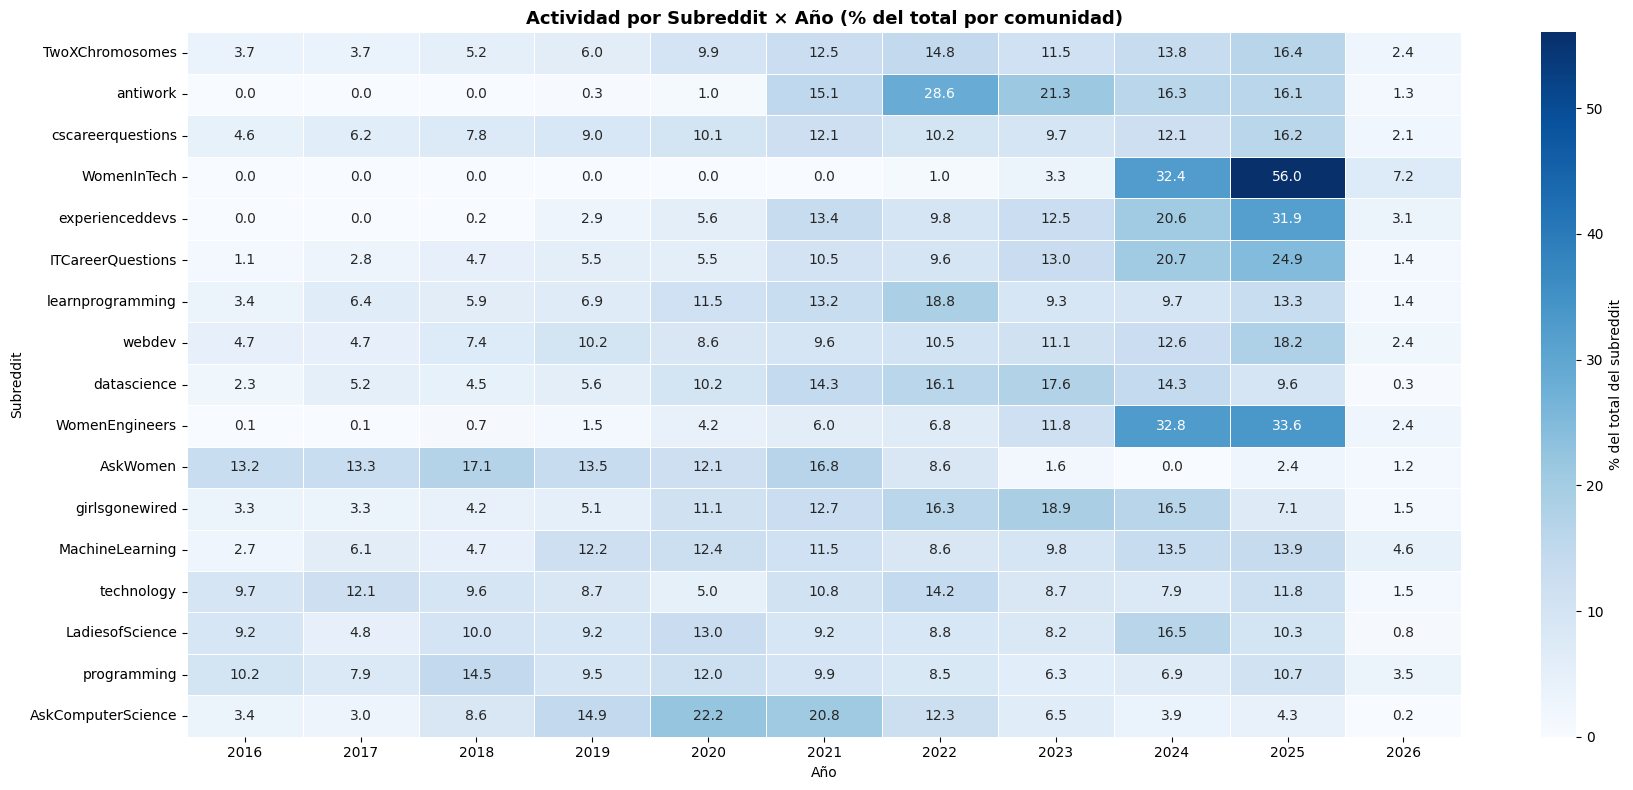

Figura guardada: ../images/exploratorio/02_heatmap_subreddit_año.png


In [ ]:
# ══════════════════════════════════════════════════════════
# HEATMAP: ACTIVIDAD POR SUBREDDIT × AÑO
# ══════════════════════════════════════════════════════════

# Crear tabla cruzada: filas = subreddits, columnas = años, valores = conteos
# unstack convierte el grupo "año" en columnas
# fill_value=0 pone 0 donde no hay datos (en vez de NaN)
pivot = df.groupby(["subreddit", "año"]).size().unstack(fill_value=0)

# Normalizar por fila: convertir conteos a porcentaje del total de cada subreddit
# Esto permite comparar comunidades con volúmenes muy diferentes
# Ejemplo: si TwoXChromosomes tiene 30,000 textos y AskComputerScience tiene 2,000
# sin normalizar no se podrían comparar, pero en porcentaje sí
# div divide cada fila entre su total, luego multiplicamos por 100 para porcentaje
pivot_norm = pivot.div(pivot.sum(axis=1), axis=0) * 100

# Ordenar los subreddits por volumen total (de mayor a menor)
orden = df["subreddit"].value_counts().index  # Lista ordenada por volumen
pivot_norm = pivot_norm.reindex(orden)          # Reordenar las filas

# ── Crear el heatmap ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 8))

sns.heatmap(
    pivot_norm,
    cmap="Blues",          # Escala de azules: más oscuro = más actividad ese año
    annot=True,            # Mostrar el valor numérico dentro de cada celda
    fmt=".1f",             # Formato: un decimal (ej: 14.5)
    linewidths=0.5,        # Grosor de las líneas que separan las celdas
    ax=ax,                 # Dibujar en el eje que creamos
    cbar_kws={"label": "% del total del subreddit"}  # Etiqueta de la barra de color
)

ax.set_title("Actividad por Subreddit × Año (% del total por comunidad)",
            fontsize=13, fontweight="bold")
ax.set_xlabel("Año")
ax.set_ylabel("Subreddit")

# ── Guardar ──────────────────────────────────────────────
plt.tight_layout()
ruta_fig = "../images/exploratorio/02_heatmap_subreddit_año.png"
plt.savefig(ruta_fig, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura guardada: {ruta_fig}")

---
## 7. Guardar dataset enriquecido

Se guarda el DataFrame con las columnas nuevas que calculamos  
(año, mes, año_mes, trimestre, num_palabras, num_caracteres)  
para que los siguientes notebooks no tengan que recalcularlas.

In [11]:
# ══════════════════════════════════════════════════════════
# GUARDAR EL DATASET ENRIQUECIDO
# El siguiente notebook (03_Limpieza) lee este archivo
# ══════════════════════════════════════════════════════════

ruta_salida = "../data/processed/reddit_data_analizado.csv"
df.to_csv(ruta_salida, index=False, encoding="utf-8")  # index=False para no guardar índice

# ── Resumen final ────────────────────────────────────────
print("=" * 55)
print("RESUMEN — NOTEBOOK 02: ANÁLISIS EXPLORATORIO")
print("=" * 55)
print(f"  Registros            : {len(df):,}")
print(f"  Subreddits           : {df['subreddit'].nunique()}")
print(f"  Posts                : {(df['tipo'] == 'post').sum():,}")
print(f"  Comentarios          : {(df['tipo'] == 'comment').sum():,}")
print(f"  Mediana de palabras  : {df['num_palabras'].median():.0f}")
print(f"  Período              : {df['año'].min()} – {df['año'].max()}")
print(f"  Dataset guardado     : {ruta_salida}")
print(f"  Figuras generadas    : 3")
print("=" * 55)
print("\n→ Siguiente paso: notebooks/03_Limpieza_Preprocesamiento.ipynb")

RESUMEN — NOTEBOOK 02: ANÁLISIS EXPLORATORIO
  Registros            : 201,182
  Subreddits           : 17
  Posts                : 13,971
  Comentarios          : 187,211
  Mediana de palabras  : 46
  Período              : 2016 – 2026
  Dataset guardado     : ../data/processed/reddit_data_analizado.csv
  Figuras generadas    : 3

→ Siguiente paso: notebooks/03_Limpieza_Preprocesamiento.ipynb
